In [11]:
import scanpy as sc
adata = sc.read("/mnt/SATA/singleCellTaru/data/adata_bbknn.h5ad")

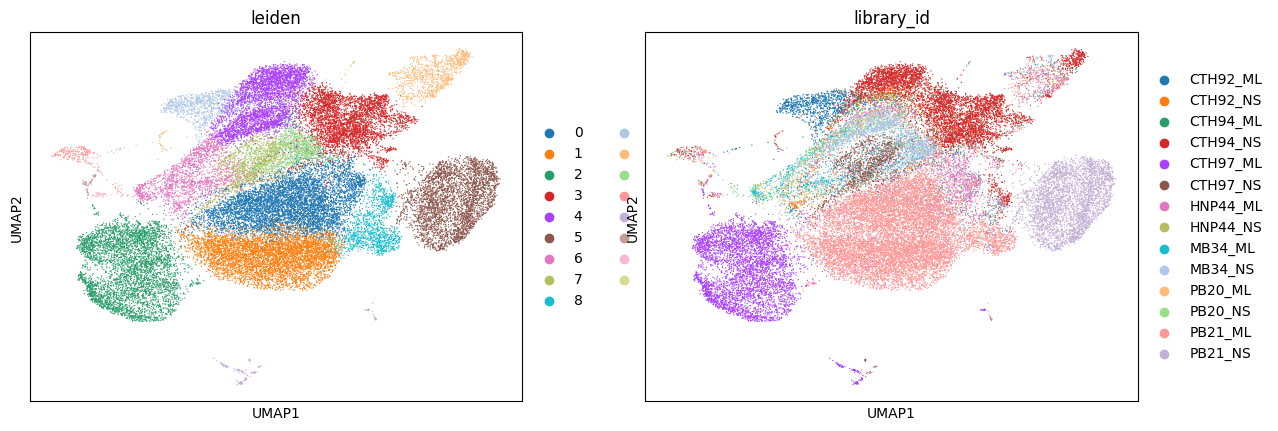

In [12]:
sc.pl.umap(adata=adata, color=["leiden", "library_id"])

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler

bdata = sc.read("/mnt/SATA/singleCellTaru/data/integratedFiltered.h5ad")

print(bdata)

def evaluate_scale_factors(
    adata,
    scale_factors=(3000, 5000, 10000),
    n_hvg=2000,
    n_pcs=10,
    resolution=0.5,
    markers=None,  # lista de genes (opcional)
    random_state=0,
    layer = "counts"
):
    """
    Avalia múltiplos scale_factors usando:
    - silhouette score
    - variância explicada PCA
    - (opcional) especificidade de marcadores (entropia)

    Retorna ranking dos melhores scale factors.
    """

    results = []

    for sf in scale_factors:
        print(f"\n[INFO] Testando scale_factor = {sf}")

        ad = adata.copy()



        # ── Normalização ─────────────────────────────────────
        sc.pp.normalize_total(ad, target_sum=sf)
        sc.pp.log1p(ad)

        # ── HVGs ─────────────────────────────────────────────
        sc.pp.highly_variable_genes(ad, n_top_genes=n_hvg, flavor="seurat_v3")
        ad = ad[:, ad.var["highly_variable"]].copy()

        # ── Escala + PCA ─────────────────────────────────────
        sc.pp.scale(ad)
        sc.tl.pca(ad, n_comps=n_pcs, random_state=random_state)

        # ── Variância PCA ────────────────────────────────────
        var_ratio = ad.uns["pca"]["variance_ratio"]
        top_pc_var = var_ratio[:5].sum()

        # ── Clustering ───────────────────────────────────────
        sc.pp.neighbors(ad, n_pcs=n_pcs)
        sc.tl.leiden(ad, resolution=resolution, random_state=random_state)

        labels = ad.obs["leiden"].astype(int).values
        embedding = ad.obsm["X_pca"][:, :n_pcs]

        # ── Silhouette ───────────────────────────────────────
        sil = silhouette_score(embedding, labels)

        # ── Entropia de marcadores (opcional) ────────────────
        marker_entropy = np.nan
        if markers is not None:
            present_markers = [g for g in markers if g in ad.var_names]

            if len(present_markers) > 0:
                expr = ad[:, present_markers].to_df()
                expr["cluster"] = labels

                avg_expr = expr.groupby("cluster").mean().T  # genes x clusters

                # normaliza por gene
                rel_expr = avg_expr.div(avg_expr.max(axis=1), axis=0)

                entropies = rel_expr.apply(
                    lambda x: entropy(x + 1e-9, base=2), axis=1
                )

                marker_entropy = entropies.mean()

        results.append({
            "scale_factor": sf,
            "top_pc_var": top_pc_var,
            "silhouette": sil,
            "marker_entropy": marker_entropy,
            "n_clusters": len(np.unique(labels))
        })

    df = pd.DataFrame(results)

    # ── Normalização dos scores ─────────────────────────────
    scaler = StandardScaler()

    df[["silhouette_z", "pca_z"]] = scaler.fit_transform(
        df[["silhouette", "top_pc_var"]]
    )

    # Se tiver entropia, incluir (invertido: menor = melhor)
    if not df["marker_entropy"].isna().all():
        df["entropy_z"] = scaler.fit_transform(df[["marker_entropy"]])
        df["rank_score"] = df["silhouette_z"] + df["pca_z"] - df["entropy_z"]
    else:
        df["rank_score"] = df["silhouette_z"] + df["pca_z"]

    df = df.sort_values("rank_score", ascending=False)

    print("\n===== RESULTADOS =====")
    print(df)

    best = df.iloc[0]
    print(f"\n🏆 Melhor scale_factor: {best['scale_factor']}")

    return df

AnnData object with n_obs × n_vars = 34931 × 17761
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'library_id'
    uns: 'neighbors', 'pca', 'predicted_doublet_colors', 'preprocessing_stats_CTH92_ML', 'preprocessing_stats_CTH92_NS', 'preprocessing_stats_CTH94_ML', 'preprocessing_stats_CTH94_NS', 'preprocessing_stats_CTH97_ML', 'preprocessing_stats_CTH97_NS', 'preprocessing_stats_HNP44_ML', 'preprocessing_stats_HNP44_NS', 'preprocessing_stats_MB34_ML', 'preprocessing_stats_MB34_NS', 'preprocessing_stats_PB20_ML', 'preprocessing_stats_PB20_NS', 'preprocessing_stats_PB21_ML', 'preprocessing_stats_PB21_NS', 'umap'
    obsm: 'X_pca', 'X_umap'


In [2]:

df_results = evaluate_scale_factors(
    bdata,
    scale_factors=[3000, 5000, 10000]
)


[INFO] Testando scale_factor = 3000


/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/usr/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 